# Active Learning: Union Approach for H. Pylori Detection

This notebook implements an active learning pipeline that combines predictions from both YOLO11x and Faster R-CNN models using a **union approach**.

## Strategy
- Load both trained models (YOLO and Faster R-CNN)
- Run inference on unannotated/test patches
- Select patches where **either model** has high confidence (> threshold)
- Rank and export top candidates for expert review (Phillip)
- Export patches with bounding boxes for labeling

## Authors
Harsha Sathish, Rohan Sanjay Patil, Vidya Padmanabha

## 1. Setup and Imports

In [1]:
import os
import sys
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

from ultralytics import YOLO

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("✓ Libraries imported successfully!")

Using device: cuda
✓ Libraries imported successfully!


## 2. Configuration

In [2]:
# =============================================================================
# CONFIGURATION - MODIFY THESE PATHS ACCORDING TO YOUR SETUP
# =============================================================================

CONFIG = {
    # Model paths
    'yolo_model_path': 'YOLO_imp/data/yolo11x.pt',  # Path to YOLO model
    'rcnn_model_path': 'RCNN_imp/outputs/best_model.pth',  # Path to Faster R-CNN model
    
    # Data paths
    'patches_dir': 'YOLO_imp/data/patches',  # Directory containing patches to analyze
    'annotations_dir': 'YOLO_imp/data/annotation',  # Directory with existing annotations (optional)
    'output_dir': 'active_learning_output',  # Output directory for results
    
    # Confidence thresholds (union approach - either model can trigger selection)
    'yolo_conf_threshold': 0.7,  # High confidence threshold for YOLO
    'rcnn_conf_threshold': 0.7,  # High confidence threshold for Faster R-CNN
    
    # IoU/DIoU thresholds
    'yolo_iou_threshold': 0.15,  # DIoU threshold for YOLO NMS
    'rcnn_iou_threshold': 0.15,  # IoU threshold for Faster R-CNN NMS
    
    # Selection parameters
    'top_n_candidates': 100,  # Number of top candidates to select
    'min_box_area': 100,  # Minimum bounding box area (pixels²)
    'max_detections_per_patch': 10,  # Maximum detections to consider per patch
    
    # Image parameters
    'yolo_img_size': 512,  # YOLO expects 512x512
    'rcnn_img_size': 640,  # Faster R-CNN expects 640x640
    
    # Diversity parameters (optional - to ensure patches from different slides)
    'ensure_slide_diversity': True,  # Ensure representation from different slides
    'max_patches_per_slide': 15,  # Maximum patches to select from each slide
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  yolo_model_path: YOLO_imp/data/yolo11x.pt
  rcnn_model_path: RCNN_imp/outputs/best_model.pth
  patches_dir: YOLO_imp/data/patches
  annotations_dir: YOLO_imp/data/annotation
  output_dir: active_learning_output
  yolo_conf_threshold: 0.7
  rcnn_conf_threshold: 0.7
  yolo_iou_threshold: 0.15
  rcnn_iou_threshold: 0.15
  top_n_candidates: 100
  min_box_area: 100
  max_detections_per_patch: 10
  yolo_img_size: 512
  rcnn_img_size: 640
  ensure_slide_diversity: True
  max_patches_per_slide: 15


## 3. Create Output Directory Structure

In [3]:
# Create output directories
OUTPUT_DIR = Path(CONFIG['output_dir'])
OUTPUT_DIR.mkdir(exist_ok=True)

# Subdirectories
(OUTPUT_DIR / 'selected_patches').mkdir(exist_ok=True)
(OUTPUT_DIR / 'visualizations').mkdir(exist_ok=True)
(OUTPUT_DIR / 'annotations').mkdir(exist_ok=True)
(OUTPUT_DIR / 'reports').mkdir(exist_ok=True)

print("✓ Output directory structure created:")
print(f"  Main: {OUTPUT_DIR}")
print(f"  - selected_patches/   (patches for Phillip to review)")
print(f"  - visualizations/     (patches with drawn bounding boxes)")
print(f"  - annotations/        (bounding box coordinates in YOLO format)")
print(f"  - reports/            (summary statistics and rankings)")

✓ Output directory structure created:
  Main: active_learning_output
  - selected_patches/   (patches for Phillip to review)
  - visualizations/     (patches with drawn bounding boxes)
  - annotations/        (bounding box coordinates in YOLO format)
  - reports/            (summary statistics and rankings)


## 4. Load Models

In [4]:
# =============================================================================
# LOAD YOLO MODEL
# =============================================================================

print("Loading YOLO11x model...")
yolo_model = YOLO(CONFIG['yolo_model_path'])
print(f"✓ YOLO model loaded from: {CONFIG['yolo_model_path']}")

Loading YOLO11x model...
✓ YOLO model loaded from: YOLO_imp/data/yolo11x.pt


In [5]:
# =============================================================================
# LOAD FASTER R-CNN MODEL
# =============================================================================

def get_rcnn_model(num_classes=2):
    """Create Faster R-CNN model architecture"""
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

print("Loading Faster R-CNN model...")
rcnn_model = get_rcnn_model(num_classes=2)  # background + H. pylori

# Load checkpoint
checkpoint = torch.load(CONFIG['rcnn_model_path'], map_location=device)
rcnn_model.load_state_dict(checkpoint['model_state_dict'])
rcnn_model.to(device)
rcnn_model.eval()

print(f"✓ Faster R-CNN model loaded from: {CONFIG['rcnn_model_path']}")
print(f"  Loaded from epoch: {checkpoint.get('epoch', 'N/A')}")

Loading Faster R-CNN model...
✓ Faster R-CNN model loaded from: RCNN_imp/outputs/best_model.pth
  Loaded from epoch: 9


## 5. Helper Functions

In [6]:
def calculate_diou(box1, box2):
    """
    Calculate Distance-IoU between two bounding boxes
    
    Args:
        box1, box2: [x_min, y_min, x_max, y_max] format
    
    Returns:
        DIoU value between 0 and 1
    """
    # Calculate IoU
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    iou = intersection / union if union > 0 else 0
    
    # Calculate center distance
    c1_x, c1_y = (box1[0] + box1[2]) / 2, (box1[1] + box1[3]) / 2
    c2_x, c2_y = (box2[0] + box2[2]) / 2, (box2[1] + box2[3]) / 2
    center_distance_sq = (c1_x - c2_x) ** 2 + (c1_y - c2_y) ** 2
    
    # Calculate diagonal distance of smallest enclosing box
    enclose_x1, enclose_y1 = min(box1[0], box2[0]), min(box1[1], box2[1])
    enclose_x2, enclose_y2 = max(box1[2], box2[2]), max(box1[3], box2[3])
    diagonal_sq = (enclose_x2 - enclose_x1) ** 2 + (enclose_y2 - enclose_y1) ** 2
    
    # DIoU
    diou = iou - (center_distance_sq / diagonal_sq) if diagonal_sq > 0 else iou
    return diou


def calculate_box_area(box):
    """Calculate area of bounding box [x_min, y_min, x_max, y_max]"""
    return (box[2] - box[0]) * (box[3] - box[1])


def extract_slide_id(filename):
    """
    Extract slide ID from filename
    Modify this function based on your naming convention
    
    Example: 'slide001_patch_0_0.png' -> 'slide001'
    """
    # Simple approach: take first part before underscore or dash
    # Adjust based on your actual filename pattern
    return filename.split('_')[0]


print("✓ Helper functions defined")

✓ Helper functions defined


## 6. Inference Functions

In [7]:
@torch.no_grad()
def run_yolo_inference(image_path, conf_threshold, iou_threshold):
    """
    Run YOLO inference on a single image
    
    Returns:
        List of detections: [{'box': [x1, y1, x2, y2], 'confidence': float, 'model': 'YOLO'}]
    """
    results = yolo_model.predict(
        image_path,
        conf=conf_threshold,
        iou=iou_threshold,
        verbose=False,
        imgsz=CONFIG['yolo_img_size']
    )
    
    detections = []
    if len(results) > 0 and results[0].boxes is not None:
        boxes = results[0].boxes
        for i in range(len(boxes)):
            box = boxes.xyxy[i].cpu().numpy()  # [x1, y1, x2, y2]
            conf = float(boxes.conf[i].cpu().numpy())
            
            # Filter by area
            if calculate_box_area(box) >= CONFIG['min_box_area']:
                detections.append({
                    'box': box.tolist(),
                    'confidence': conf,
                    'model': 'YOLO'
                })
    
    return detections


@torch.no_grad()
def run_rcnn_inference(image_path, conf_threshold):
    """
    Run Faster R-CNN inference on a single image
    
    Returns:
        List of detections: [{'box': [x1, y1, x2, y2], 'confidence': float, 'model': 'RCNN'}]
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    
    # Resize if needed
    if image.size != (CONFIG['rcnn_img_size'], CONFIG['rcnn_img_size']):
        image = image.resize((CONFIG['rcnn_img_size'], CONFIG['rcnn_img_size']), Image.BILINEAR)
    
    # Convert to tensor and normalize
    image_tensor = F.to_tensor(image).to(device)
    
    # Run inference
    predictions = rcnn_model([image_tensor])[0]
    
    # Extract predictions
    detections = []
    boxes = predictions['boxes'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    
    for box, score, label in zip(boxes, scores, labels):
        # Filter by confidence and class (label=1 is H. pylori, label=0 is background)
        if score >= conf_threshold and label == 1:
            # Filter by area
            if calculate_box_area(box) >= CONFIG['min_box_area']:
                detections.append({
                    'box': box.tolist(),
                    'confidence': float(score),
                    'model': 'RCNN'
                })
    
    return detections


print("✓ Inference functions defined")

✓ Inference functions defined


## 7. Run Inference on All Patches

In [8]:
# Get all patch files
patches_dir = Path(CONFIG['patches_dir'])
patch_files = list(patches_dir.glob('*.png')) + list(patches_dir.glob('*.jpg'))

print(f"Found {len(patch_files)} patches to process")
print(f"\nStarting inference...\n")

# Store all results
all_results = []

# Run inference on all patches
for patch_path in tqdm(patch_files, desc="Processing patches"):
    try:
        # Run YOLO inference
        yolo_detections = run_yolo_inference(
            str(patch_path),
            CONFIG['yolo_conf_threshold'],
            CONFIG['yolo_iou_threshold']
        )
        
        # Run Faster R-CNN inference
        rcnn_detections = run_rcnn_inference(
            str(patch_path),
            CONFIG['rcnn_conf_threshold']
        )
        
        # Combine detections (union approach)
        all_detections = yolo_detections + rcnn_detections
        
        # Only keep patches with at least one detection
        if len(all_detections) > 0:
            # Limit detections per patch
            all_detections = sorted(
                all_detections,
                key=lambda x: x['confidence'],
                reverse=True
            )[:CONFIG['max_detections_per_patch']]
            
            # Calculate aggregate metrics
            max_confidence = max(d['confidence'] for d in all_detections)
            avg_confidence = np.mean([d['confidence'] for d in all_detections])
            num_yolo = sum(1 for d in all_detections if d['model'] == 'YOLO')
            num_rcnn = sum(1 for d in all_detections if d['model'] == 'RCNN')
            
            all_results.append({
                'patch_path': str(patch_path),
                'patch_name': patch_path.name,
                'slide_id': extract_slide_id(patch_path.name),
                'detections': all_detections,
                'num_detections': len(all_detections),
                'num_yolo_detections': num_yolo,
                'num_rcnn_detections': num_rcnn,
                'max_confidence': max_confidence,
                'avg_confidence': avg_confidence,
                'both_models': num_yolo > 0 and num_rcnn > 0,
            })
    
    except Exception as e:
        print(f"Error processing {patch_path.name}: {str(e)}")
        continue

print(f"\n✓ Inference complete!")
print(f"  Total patches processed: {len(patch_files)}")
print(f"  Patches with detections: {len(all_results)}")
print(f"  Detection rate: {len(all_results)/len(patch_files)*100:.1f}%")

Found 2602 patches to process

Starting inference...



Processing patches: 100%|███████████████████| 2602/2602 [03:05<00:00, 14.03it/s]


✓ Inference complete!
  Total patches processed: 2602
  Patches with detections: 1313
  Detection rate: 50.5%


## 8. Analyze Detection Statistics

In [9]:
# Create statistics dataframe
df_results = pd.DataFrame(all_results)

if len(df_results) > 0:
    print("=" * 70)
    print("DETECTION STATISTICS")
    print("=" * 70)
    
    print(f"\nOverall Statistics:")
    print(f"  Patches with detections: {len(df_results)}")
    print(f"  Total detections: {df_results['num_detections'].sum()}")
    print(f"  Avg detections per patch: {df_results['num_detections'].mean():.2f}")
    
    print(f"\nModel-specific Statistics:")
    print(f"  YOLO only: {sum((df_results['num_yolo_detections'] > 0) & (df_results['num_rcnn_detections'] == 0))}")
    print(f"  RCNN only: {sum((df_results['num_rcnn_detections'] > 0) & (df_results['num_yolo_detections'] == 0))}")
    print(f"  Both models: {sum(df_results['both_models'])}")
    
    print(f"\nConfidence Statistics:")
    print(f"  Max confidence range: [{df_results['max_confidence'].min():.3f}, {df_results['max_confidence'].max():.3f}]")
    print(f"  Avg confidence range: [{df_results['avg_confidence'].min():.3f}, {df_results['avg_confidence'].max():.3f}]")
    print(f"  Mean max confidence: {df_results['max_confidence'].mean():.3f}")
    
    print(f"\nSlide Distribution:")
    slide_counts = df_results['slide_id'].value_counts()
    print(f"  Number of unique slides: {len(slide_counts)}")
    print(f"  Patches per slide range: [{slide_counts.min()}, {slide_counts.max()}]")
    print(f"  Avg patches per slide: {slide_counts.mean():.1f}")
    
else:
    print("⚠️ No detections found with current thresholds!")
    print("Consider lowering confidence thresholds.")

DETECTION STATISTICS

Overall Statistics:
  Patches with detections: 1313
  Total detections: 1361
  Avg detections per patch: 1.04

Model-specific Statistics:
  YOLO only: 68
  RCNN only: 1210
  Both models: 35

Confidence Statistics:
  Max confidence range: [0.700, 0.949]
  Avg confidence range: [0.700, 0.931]
  Mean max confidence: 0.752

Slide Distribution:
  Number of unique slides: 1
  Patches per slide range: [1313, 1313]
  Avg patches per slide: 1313.0


## 9. Visualize Detection Distribution

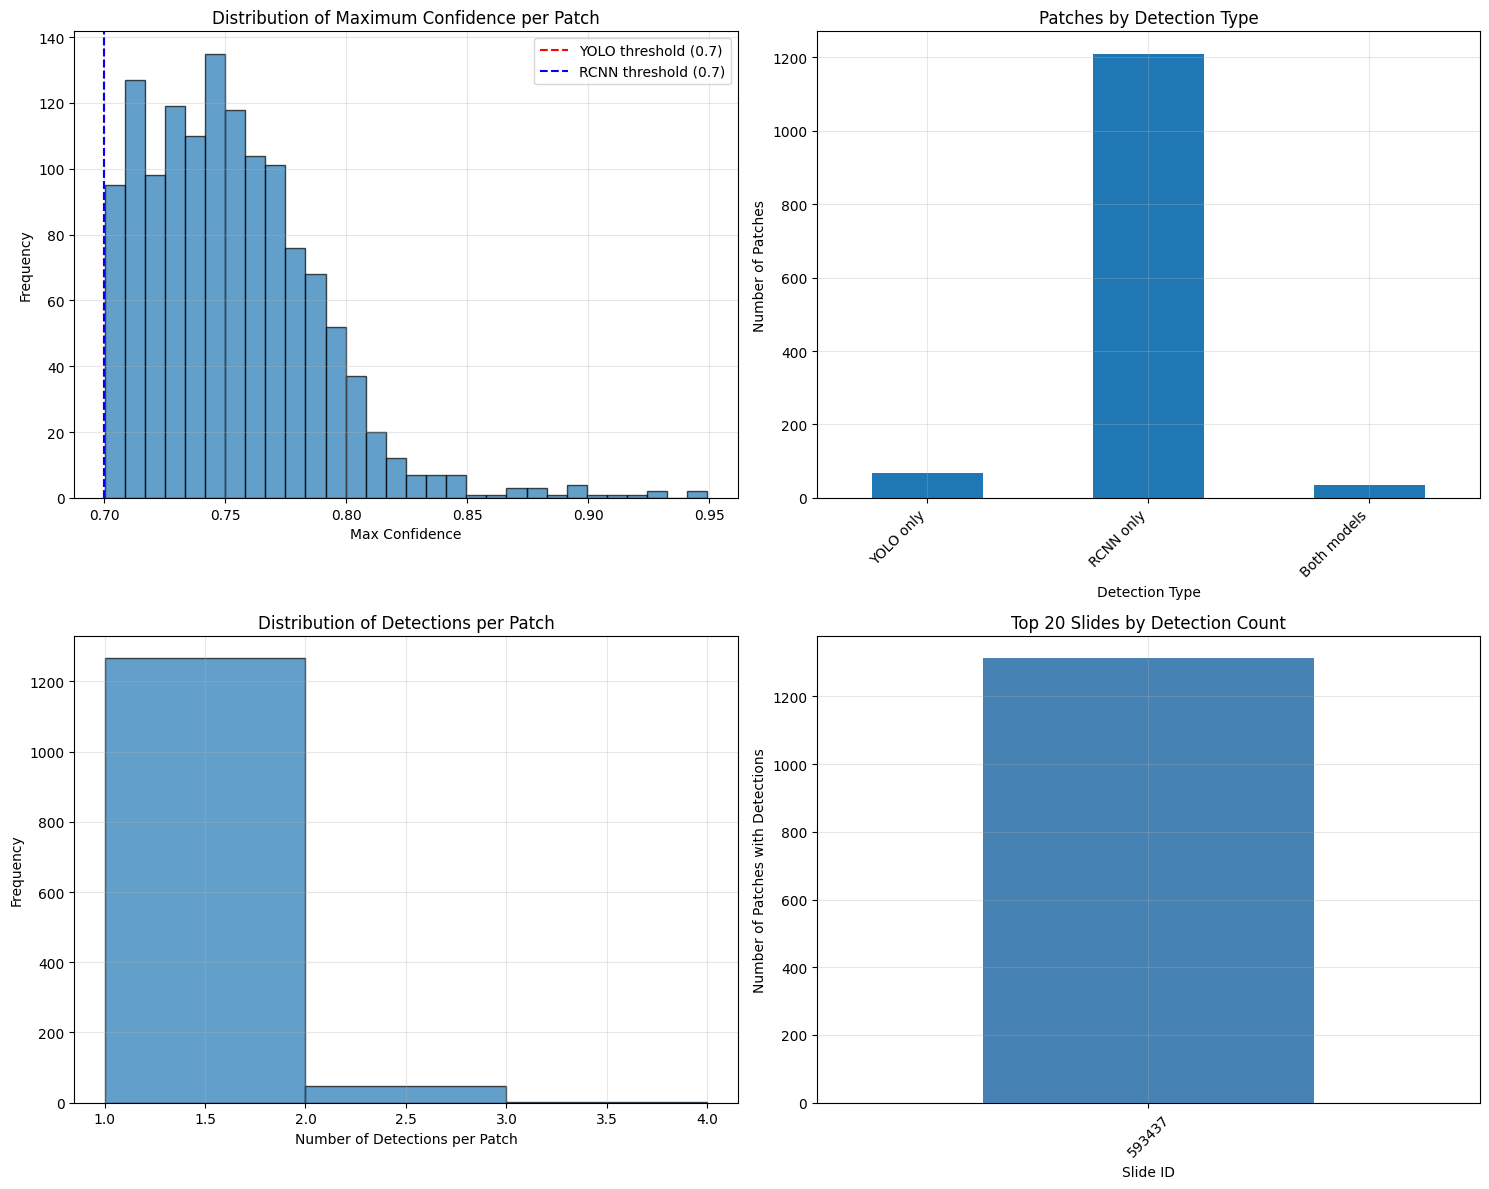

✓ Visualization saved to: active_learning_output/reports/detection_statistics.png


In [10]:
if len(df_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Confidence distribution
    axes[0, 0].hist(df_results['max_confidence'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(CONFIG['yolo_conf_threshold'], color='r', linestyle='--', 
                       label=f"YOLO threshold ({CONFIG['yolo_conf_threshold']})")
    axes[0, 0].axvline(CONFIG['rcnn_conf_threshold'], color='b', linestyle='--',
                       label=f"RCNN threshold ({CONFIG['rcnn_conf_threshold']})")
    axes[0, 0].set_xlabel('Max Confidence')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Maximum Confidence per Patch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Model detection counts
    model_counts = pd.DataFrame({
        'YOLO only': [sum((df_results['num_yolo_detections'] > 0) & (df_results['num_rcnn_detections'] == 0))],
        'RCNN only': [sum((df_results['num_rcnn_detections'] > 0) & (df_results['num_yolo_detections'] == 0))],
        'Both models': [sum(df_results['both_models'])]
    })
    model_counts.T.plot(kind='bar', ax=axes[0, 1], legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 1].set_xlabel('Detection Type')
    axes[0, 1].set_ylabel('Number of Patches')
    axes[0, 1].set_title('Patches by Detection Type')
    axes[0, 1].set_xticklabels(model_counts.columns, rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Detections per patch
    axes[1, 0].hist(df_results['num_detections'], bins=range(1, df_results['num_detections'].max()+2),
                    edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Number of Detections per Patch')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Detections per Patch')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Slide distribution
    slide_counts = df_results['slide_id'].value_counts().head(20)
    slide_counts.plot(kind='bar', ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_xlabel('Slide ID')
    axes[1, 1].set_ylabel('Number of Patches with Detections')
    axes[1, 1].set_title('Top 20 Slides by Detection Count')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'reports' / 'detection_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved to:", OUTPUT_DIR / 'reports' / 'detection_statistics.png')

## 10. Select Top Candidates for Review

In [11]:
if len(df_results) > 0:
    # Rank patches by maximum confidence
    df_ranked = df_results.sort_values('max_confidence', ascending=False).reset_index(drop=True)
    
    # Apply diversity constraint if enabled
    if CONFIG['ensure_slide_diversity']:
        selected_patches = []
        slide_counts = defaultdict(int)
        
        for _, row in df_ranked.iterrows():
            slide_id = row['slide_id']
            
            # Check if we can add more from this slide
            if slide_counts[slide_id] < CONFIG['max_patches_per_slide']:
                selected_patches.append(row)
                slide_counts[slide_id] += 1
            
            # Stop when we have enough candidates
            if len(selected_patches) >= CONFIG['top_n_candidates']:
                break
        
        df_selected = pd.DataFrame(selected_patches)
        print(f"\n✓ Selected {len(df_selected)} patches with slide diversity constraint")
        print(f"  Max patches per slide: {CONFIG['max_patches_per_slide']}")
        print(f"  Slides represented: {len(slide_counts)}")
        
    else:
        # Simple top-N selection
        df_selected = df_ranked.head(CONFIG['top_n_candidates'])
        print(f"\n✓ Selected top {len(df_selected)} patches by confidence")
    
    # Print selection summary
    print("\n" + "="*70)
    print("SELECTED CANDIDATES SUMMARY")
    print("="*70)
    print(f"Number of patches: {len(df_selected)}")
    print(f"Confidence range: [{df_selected['max_confidence'].min():.3f}, {df_selected['max_confidence'].max():.3f}]")
    print(f"Avg confidence: {df_selected['max_confidence'].mean():.3f}")
    print(f"\nDetection breakdown:")
    print(f"  YOLO only: {sum((df_selected['num_yolo_detections'] > 0) & (df_selected['num_rcnn_detections'] == 0))}")
    print(f"  RCNN only: {sum((df_selected['num_rcnn_detections'] > 0) & (df_selected['num_yolo_detections'] == 0))}")
    print(f"  Both models: {sum(df_selected['both_models'])}")
    
else:
    print("⚠️ No patches to select!")
    df_selected = pd.DataFrame()


✓ Selected 15 patches with slide diversity constraint
  Max patches per slide: 15
  Slides represented: 1

SELECTED CANDIDATES SUMMARY
Number of patches: 15
Confidence range: [0.876, 0.949]
Avg confidence: 0.907

Detection breakdown:
  YOLO only: 11
  RCNN only: 0
  Both models: 4


## 11. Visualization Function

In [12]:
def draw_detections_on_image(image_path, detections, save_path):
    """
    Draw bounding boxes on image and save
    
    Args:
        image_path: Path to original image
        detections: List of detection dictionaries
        save_path: Path to save annotated image
    """
    # Load image
    image = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    
    # Try to load a font (fallback to default if not available)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except:
        font = ImageFont.load_default()
    
    # Define colors
    colors = {
        'YOLO': (255, 0, 0),      # Red
        'RCNN': (0, 0, 255),      # Blue
    }
    
    # Draw each detection
    for det in detections:
        box = det['box']
        conf = det['confidence']
        model = det['model']
        color = colors[model]
        
        # Draw rectangle
        draw.rectangle(box, outline=color, width=3)
        
        # Draw label
        label = f"{model}: {conf:.2f}"
        
        # Get text bounding box for background
        bbox = draw.textbbox((box[0], box[1] - 20), label, font=font)
        draw.rectangle(bbox, fill=color)
        draw.text((box[0], box[1] - 20), label, fill='white', font=font)
    
    # Save image
    image.save(save_path)

print("✓ Visualization function defined")

✓ Visualization function defined


## 12. Export Selected Patches

In [13]:
if len(df_selected) > 0:
    print("Exporting selected patches...\n")
    
    export_data = []
    
    for idx, row in tqdm(df_selected.iterrows(), total=len(df_selected), desc="Exporting"):
        patch_name = row['patch_name']
        patch_path = row['patch_path']
        detections = row['detections']
        
        # Copy original patch
        shutil.copy(patch_path, OUTPUT_DIR / 'selected_patches' / patch_name)
        
        # Create visualization with bounding boxes
        vis_path = OUTPUT_DIR / 'visualizations' / patch_name
        draw_detections_on_image(patch_path, detections, vis_path)
        
        # Save annotation in YOLO format
        annotation_path = OUTPUT_DIR / 'annotations' / f"{Path(patch_name).stem}.txt"
        with open(annotation_path, 'w') as f:
            # Load image to get dimensions
            img = Image.open(patch_path)
            img_w, img_h = img.size
            
            for det in detections:
                box = det['box']  # [x_min, y_min, x_max, y_max]
                
                # Convert to YOLO format: class_id x_center y_center width height (all normalized)
                x_center = ((box[0] + box[2]) / 2) / img_w
                y_center = ((box[1] + box[3]) / 2) / img_h
                width = (box[2] - box[0]) / img_w
                height = (box[3] - box[1]) / img_h
                
                # Class 0 for H. pylori
                f.write(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        
        # Store for report
        export_data.append({
            'rank': idx + 1,
            'patch_name': patch_name,
            'slide_id': row['slide_id'],
            'max_confidence': row['max_confidence'],
            'avg_confidence': row['avg_confidence'],
            'num_detections': row['num_detections'],
            'yolo_detections': row['num_yolo_detections'],
            'rcnn_detections': row['num_rcnn_detections'],
            'both_models': row['both_models'],
        })
    
    # Save detailed report
    df_export = pd.DataFrame(export_data)
    df_export.to_csv(OUTPUT_DIR / 'reports' / 'selected_patches_report.csv', index=False)
    
    # Save configuration
    with open(OUTPUT_DIR / 'reports' / 'config.json', 'w') as f:
        json.dump(CONFIG, f, indent=2)
    
    print("\n✓ Export complete!")
    print(f"  Original patches: {OUTPUT_DIR / 'selected_patches'}")
    print(f"  Visualizations: {OUTPUT_DIR / 'visualizations'}")
    print(f"  YOLO annotations: {OUTPUT_DIR / 'annotations'}")
    print(f"  Report: {OUTPUT_DIR / 'reports' / 'selected_patches_report.csv'}")
    print(f"  Config: {OUTPUT_DIR / 'reports' / 'config.json'}")
else:
    print("⚠️ No patches to export!")

Exporting selected patches...



Exporting: 100%|████████████████████████████████| 15/15 [00:01<00:00,  8.49it/s]


✓ Export complete!
  Original patches: active_learning_output/selected_patches
  Visualizations: active_learning_output/visualizations
  YOLO annotations: active_learning_output/annotations
  Report: active_learning_output/reports/selected_patches_report.csv
  Config: active_learning_output/reports/config.json


## 13. Display Sample Visualizations

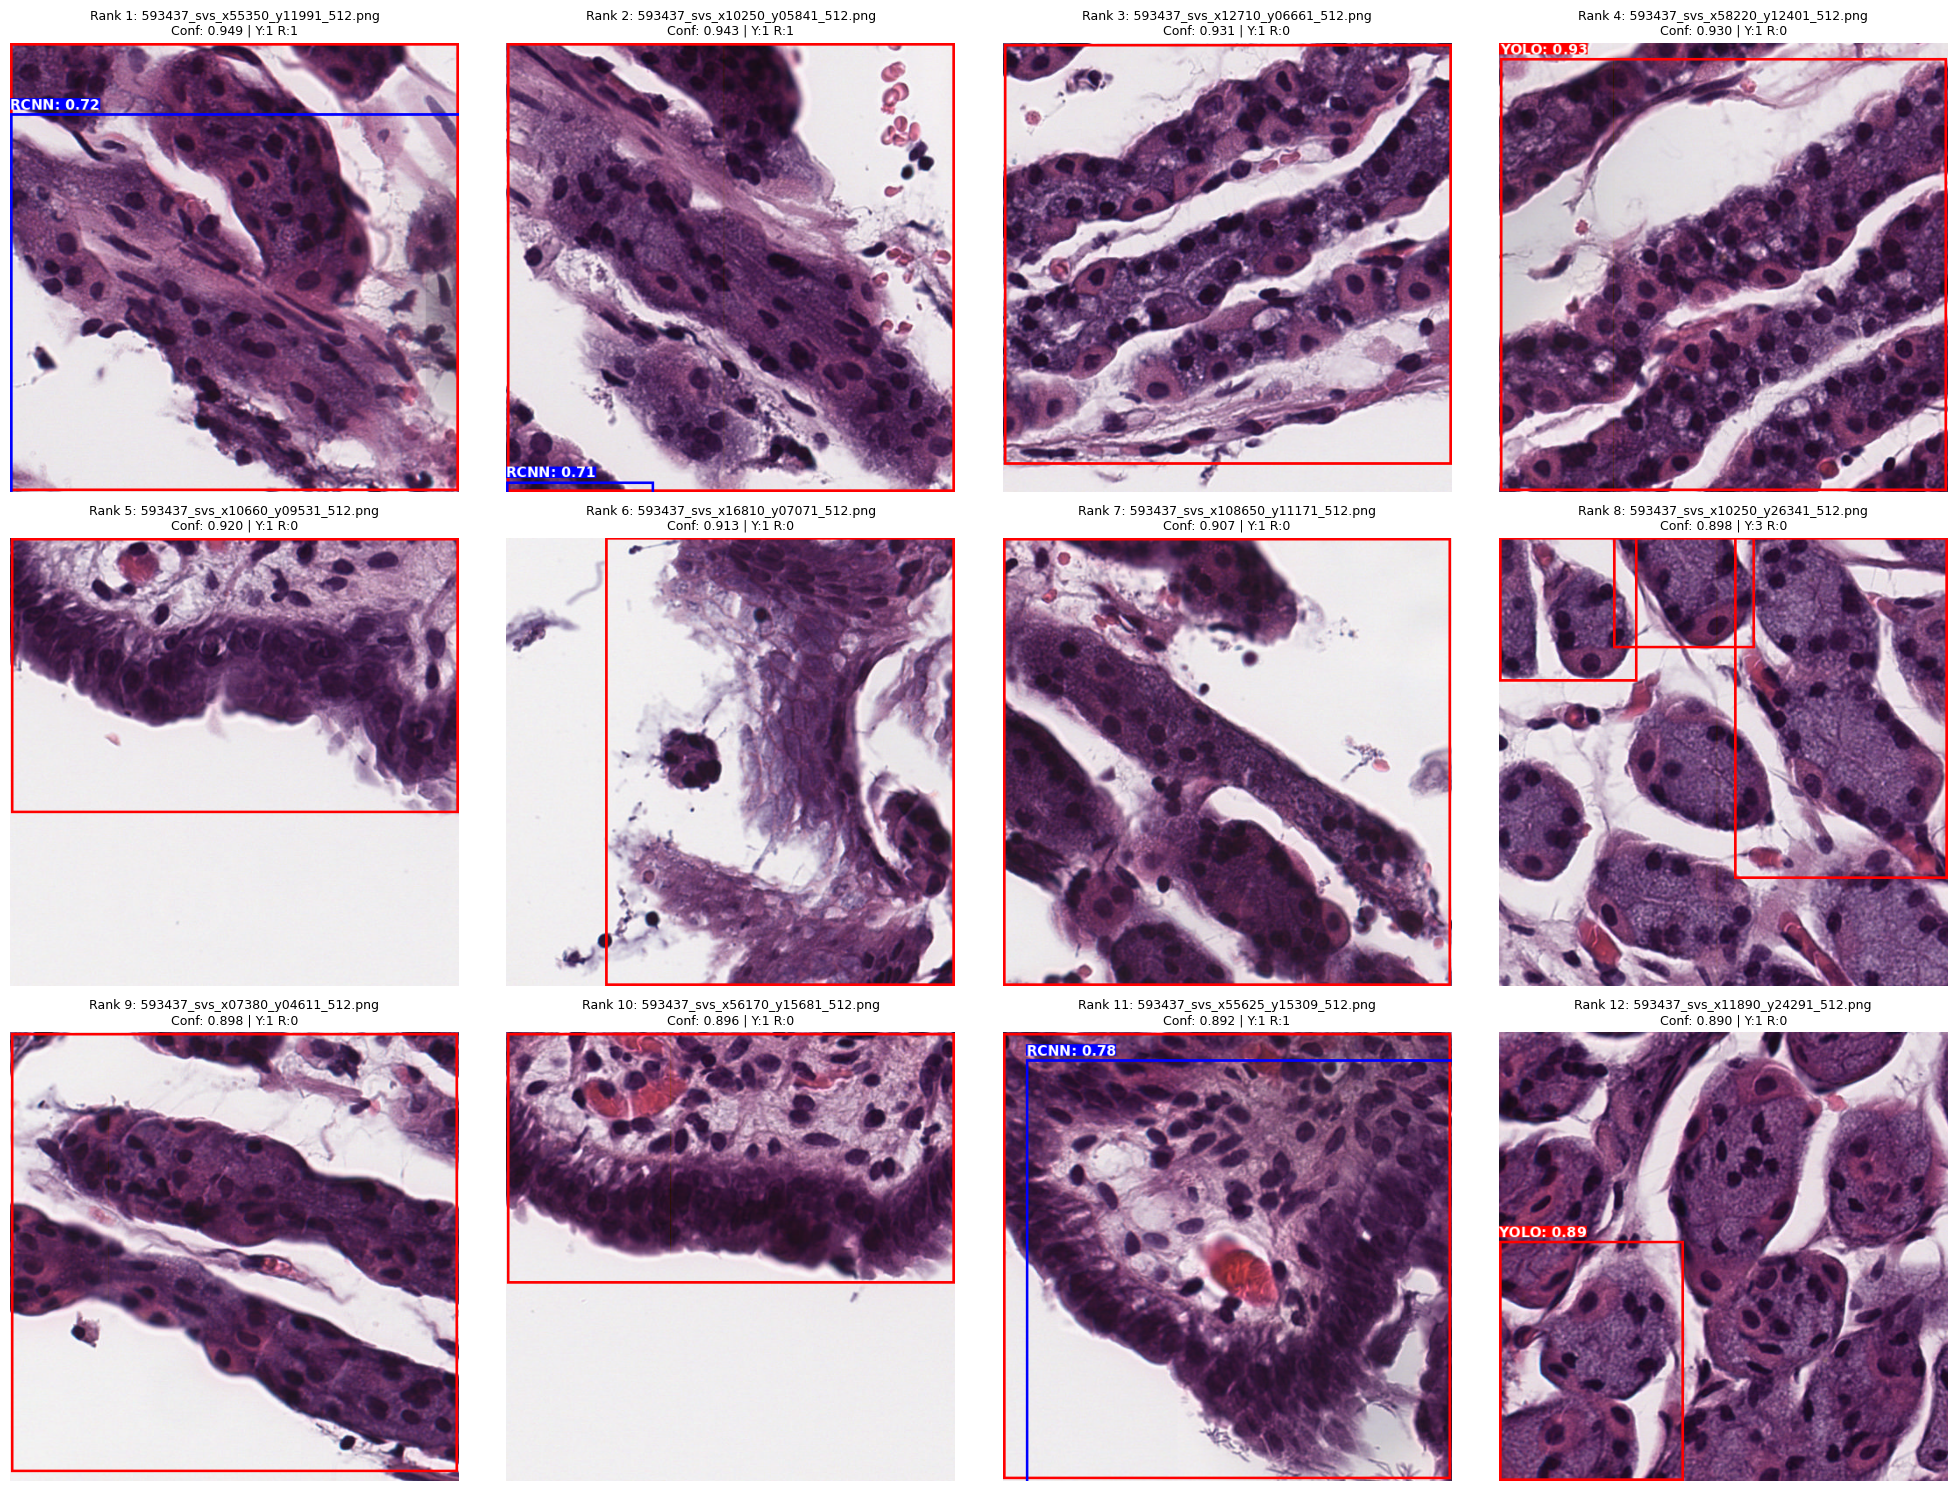

✓ Preview saved to: active_learning_output/reports/top_candidates_preview.png


In [14]:
if len(df_selected) > 0:
    # Show top 12 candidates
    num_samples = min(12, len(df_selected))
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for idx in range(num_samples):
        row = df_selected.iloc[idx]
        vis_path = OUTPUT_DIR / 'visualizations' / row['patch_name']
        
        img = Image.open(vis_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        
        # Title with key info
        title = f"Rank {idx+1}: {row['patch_name']}\n"
        title += f"Conf: {row['max_confidence']:.3f} | "
        title += f"Y:{row['num_yolo_detections']} R:{row['num_rcnn_detections']}"
        axes[idx].set_title(title, fontsize=9)
    
    # Hide unused subplots
    for idx in range(num_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'reports' / 'top_candidates_preview.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    print("✓ Preview saved to:", OUTPUT_DIR / 'reports' / 'top_candidates_preview.png')

## 14. Generate Summary Report

In [15]:
# Generate markdown summary report
report_lines = []
report_lines.append("# Active Learning - Union Approach Report\n")
report_lines.append(f"**Generated on:** {pd.Timestamp.now()}\n\n")

report_lines.append("## Configuration\n")
report_lines.append(f"- YOLO model: `{CONFIG['yolo_model_path']}`\n")
report_lines.append(f"- RCNN model: `{CONFIG['rcnn_model_path']}`\n")
report_lines.append(f"- YOLO confidence threshold: {CONFIG['yolo_conf_threshold']}\n")
report_lines.append(f"- RCNN confidence threshold: {CONFIG['rcnn_conf_threshold']}\n")
report_lines.append(f"- Top N candidates: {CONFIG['top_n_candidates']}\n\n")

if len(df_results) > 0:
    report_lines.append("## Detection Statistics\n")
    report_lines.append(f"- Total patches processed: {len(patch_files)}\n")
    report_lines.append(f"- Patches with detections: {len(df_results)} ({len(df_results)/len(patch_files)*100:.1f}%)\n")
    report_lines.append(f"- Total detections: {df_results['num_detections'].sum()}\n")
    report_lines.append(f"- Avg detections per patch: {df_results['num_detections'].mean():.2f}\n\n")
    
    report_lines.append("### Model Breakdown\n")
    report_lines.append(f"- YOLO only: {sum((df_results['num_yolo_detections'] > 0) & (df_results['num_rcnn_detections'] == 0))}\n")
    report_lines.append(f"- RCNN only: {sum((df_results['num_rcnn_detections'] > 0) & (df_results['num_yolo_detections'] == 0))}\n")
    report_lines.append(f"- Both models: {sum(df_results['both_models'])}\n\n")

if len(df_selected) > 0:
    report_lines.append("## Selected Candidates\n")
    report_lines.append(f"- Number selected: {len(df_selected)}\n")
    report_lines.append(f"- Confidence range: [{df_selected['max_confidence'].min():.3f}, {df_selected['max_confidence'].max():.3f}]\n")
    report_lines.append(f"- Unique slides: {df_selected['slide_id'].nunique()}\n\n")
    
    report_lines.append("### Top 10 Candidates\n")
    report_lines.append("| Rank | Patch Name | Slide | Confidence | YOLO | RCNN | Both |\n")
    report_lines.append("|------|------------|-------|------------|------|------|------|\n")
    
    for idx, row in df_selected.head(10).iterrows():
        both = "✓" if row['both_models'] else ""
        report_lines.append(
            f"| {idx+1} | {row['patch_name']} | {row['slide_id']} | "
            f"{row['max_confidence']:.3f} | {row['num_yolo_detections']} | "
            f"{row['num_rcnn_detections']} | {both} |\n"
        )

report_lines.append("\n## Next Steps\n")
report_lines.append("1. Review patches in `selected_patches/` directory\n")
report_lines.append("2. Check visualizations in `visualizations/` directory\n")
report_lines.append("3. Send patches to Phillip for expert annotation\n")
report_lines.append("4. Update training dataset with new annotations\n")
report_lines.append("5. Retrain models with expanded dataset\n")

# Save report
report_path = OUTPUT_DIR / 'reports' / 'summary_report.md'
with open(report_path, 'w') as f:
    f.writelines(report_lines)

print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)
print(''.join(report_lines))
print(f"\n✓ Report saved to: {report_path}")


SUMMARY REPORT
# Active Learning - Union Approach Report
**Generated on:** 2025-11-26 16:11:28.343620

## Configuration
- YOLO model: `YOLO_imp/data/yolo11x.pt`
- RCNN model: `RCNN_imp/outputs/best_model.pth`
- YOLO confidence threshold: 0.7
- RCNN confidence threshold: 0.7
- Top N candidates: 100

## Detection Statistics
- Total patches processed: 2602
- Patches with detections: 1313 (50.5%)
- Total detections: 1361
- Avg detections per patch: 1.04

### Model Breakdown
- YOLO only: 68
- RCNN only: 1210
- Both models: 35

## Selected Candidates
- Number selected: 15
- Confidence range: [0.876, 0.949]
- Unique slides: 1

### Top 10 Candidates
| Rank | Patch Name | Slide | Confidence | YOLO | RCNN | Both |
|------|------------|-------|------------|------|------|------|
| 1 | 593437_svs_x55350_y11991_512.png | 593437 | 0.949 | 1 | 1 | ✓ |
| 2 | 593437_svs_x10250_y05841_512.png | 593437 | 0.943 | 1 | 1 | ✓ |
| 3 | 593437_svs_x12710_y06661_512.png | 593437 | 0.931 | 1 | 0 |  |
| 4 | 593437

## 15. Create README for Phillip

In [16]:
readme_content = f"""# Active Learning - Patch Review Instructions

Dear Phillip,

This package contains {len(df_selected) if len(df_selected) > 0 else 0} patches selected by our H. pylori detection system for expert review.

## What's Inside

- **selected_patches/**: Original patch images for your review
- **visualizations/**: Same patches with AI-predicted bounding boxes overlaid
  - Red boxes = YOLO detections
  - Blue boxes = Faster R-CNN detections
- **annotations/**: Predicted bounding boxes in YOLO format (.txt files)
- **reports/**: 
  - `selected_patches_report.csv`: Detailed information about each patch
  - `summary_report.md`: Overall statistics
  - `top_candidates_preview.png`: Quick visual overview

## How These Were Selected

These patches were selected using a **union approach**:
- Both YOLO and Faster R-CNN models ran inference on all patches
- Patches where **either model** showed high confidence (>{CONFIG['yolo_conf_threshold']}) were selected
- They are ranked by confidence, with the most confident detections first

## What We Need from You

Please review each patch in `selected_patches/` and:
1. Confirm whether H. pylori is present
2. If present, verify/correct the bounding box locations (see `visualizations/`)
3. Mark any false positives (AI detected bacteria but none present)
4. Mark any false negatives (bacteria present but AI missed it)

## Priority

Patches are already ranked by confidence. We recommend reviewing in order, starting with:
- Patches where both models agreed (most reliable)
- High-confidence single-model detections

## Questions?

Contact: Harsha, Rohan, or Vidya

Thank you for your expertise!
"""

with open(OUTPUT_DIR / 'README_FOR_PHILLIP.md', 'w') as f:
    f.write(readme_content)

print("✓ README created for Phillip")
print(f"  Location: {OUTPUT_DIR / 'README_FOR_PHILLIP.md'}")

✓ README created for Phillip
  Location: active_learning_output/README_FOR_PHILLIP.md


## 16. Final Summary

In [17]:
print("\n" + "="*70)
print("ACTIVE LEARNING PIPELINE COMPLETE!")
print("="*70)

if len(df_selected) > 0:
    print(f"\n✅ Successfully selected {len(df_selected)} patches for review")
    print(f"\nAll outputs saved to: {OUTPUT_DIR}")
    print("\nNext steps:")
    print("  1. Review the visualizations to verify detection quality")
    print("  2. Package the 'active_learning_output' folder")
    print("  3. Send to Phillip for expert annotation")
    print("  4. Integrate validated annotations into training dataset")
    print("  5. Retrain models with expanded, high-quality dataset")
    
    print("\n📊 Key Statistics:")
    print(f"  - Detection rate: {len(df_results)/len(patch_files)*100:.1f}%")
    print(f"  - Avg confidence: {df_selected['max_confidence'].mean():.3f}")
    print(f"  - Both models agree: {sum(df_selected['both_models'])} patches")
    print(f"  - Unique slides: {df_selected['slide_id'].nunique()}")
else:
    print("\n⚠️ No patches selected!")
    print("\nRecommendations:")
    print("  1. Lower the confidence thresholds in CONFIG")
    print("  2. Check that model paths are correct")
    print("  3. Verify patch directory contains valid images")
    print("  4. Review model performance on validation set")

print("\n" + "="*70)


ACTIVE LEARNING PIPELINE COMPLETE!

✅ Successfully selected 15 patches for review

All outputs saved to: active_learning_output

Next steps:
  1. Review the visualizations to verify detection quality
  2. Package the 'active_learning_output' folder
  3. Send to Phillip for expert annotation
  4. Integrate validated annotations into training dataset
  5. Retrain models with expanded, high-quality dataset

📊 Key Statistics:
  - Detection rate: 50.5%
  - Avg confidence: 0.907
  - Both models agree: 4 patches
  - Unique slides: 1

